In [1]:
#First we will import all the necessary libraries then we will need to build our model
import warnings
warnings.filterwarnings("ignore") # this will filter out the warnings

import pandas as pd, numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,roc_auc_score,roc_curve
from sklearn.model_selection import GridSearchCV

In [2]:
#load csv file into this model
inp = pd.read_csv('dataset_assignment1.csv')

In [3]:
#check if the file is loaded correctly as well as how data looks like
inp.head()

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


In [4]:
#check the shape of the data
inp.shape

(700, 10)

In [5]:
#tells about dtypes and if there is null value or not
inp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   feature1  700 non-null    int64
 1   feature2  700 non-null    int64
 2   feature3  700 non-null    int64
 3   feature4  700 non-null    int64
 4   feature5  700 non-null    int64
 5   feature6  700 non-null    int64
 6   feature7  700 non-null    int64
 7   feature8  700 non-null    int64
 8   feature9  700 non-null    int64
 9   class     700 non-null    int64
dtypes: int64(10)
memory usage: 54.8 KB


In [6]:
inp.describe()
#to find the mean, count standard deviation of data 
#it basically describes the data

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,class
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,4.415714,3.131429,3.204286,2.804286,3.214286,3.557143,3.437143,2.864286,1.588571,0.344286
std,2.814236,3.050343,2.970958,2.854153,2.213193,3.613026,2.436676,3.052265,1.713995,0.475475
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,0.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000


In [7]:
#confirm if there is any null value in the features
inp.isnull().sum()

feature1    0
feature2    0
feature3    0
feature4    0
feature5    0
feature6    0
feature7    0
feature8    0
feature9    0
class       0
dtype: int64

In [8]:
inp.columns
#it tells us about all the attributes of the data 

Index(['feature1', 'feature2', 'feature3', 'feature4', 'feature5', 'feature6',
       'feature7', 'feature8', 'feature9', 'class'],
      dtype='object')

In [9]:
#we run a for loop to find the values in each column and their value count
for column in inp.columns:
    print(f"Value counts for column '{column}':")
    print(inp[column].value_counts())
    print()

Value counts for column 'feature1':
feature1
1     145
5     130
3     109
4      80
10     69
2      50
8      46
6      34
7      23
9      14
Name: count, dtype: int64

Value counts for column 'feature2':
feature2
1     385
10     67
3      52
2      45
4      40
5      30
8      29
6      27
7      19
9       6
Name: count, dtype: int64

Value counts for column 'feature3':
feature3
1     354
2      59
10     58
3      56
4      44
5      34
6      30
7      30
8      28
9       7
Name: count, dtype: int64

Value counts for column 'feature4':
feature4
1     408
3      58
2      58
10     55
4      33
8      25
5      23
6      22
7      13
9       5
Name: count, dtype: int64

Value counts for column 'feature5':
feature5
2     387
3      72
4      48
1      47
6      41
5      39
10     31
8      21
7      12
9       2
Name: count, dtype: int64

Value counts for column 'feature6':
feature6
1     403
10    132
2      34
5      34
3      30
4      22
8      22
7      10
9       9
6    

In [10]:
#here we performs a nested for loop to find the percentage as of the value counts
#this will tell us if there will be any class imbalance
for column in inp.columns:
    print(f"Value counts for column '{column}':")
    counts = inp[column].value_counts()
    total_count = counts.sum()
    for value, count in counts.items():
        percentage = (count / total_count) * 100
        print(f"{value}: {percentage:.2f}%")
    print()

Value counts for column 'feature1':
1: 20.71%
5: 18.57%
3: 15.57%
4: 11.43%
10: 9.86%
2: 7.14%
8: 6.57%
6: 4.86%
7: 3.29%
9: 2.00%

Value counts for column 'feature2':
1: 55.00%
10: 9.57%
3: 7.43%
2: 6.43%
4: 5.71%
5: 4.29%
8: 4.14%
6: 3.86%
7: 2.71%
9: 0.86%

Value counts for column 'feature3':
1: 50.57%
2: 8.43%
10: 8.29%
3: 8.00%
4: 6.29%
5: 4.86%
6: 4.29%
7: 4.29%
8: 4.00%
9: 1.00%

Value counts for column 'feature4':
1: 58.29%
3: 8.29%
2: 8.29%
10: 7.86%
4: 4.71%
8: 3.57%
5: 3.29%
6: 3.14%
7: 1.86%
9: 0.71%

Value counts for column 'feature5':
2: 55.29%
3: 10.29%
4: 6.86%
1: 6.71%
6: 5.86%
5: 5.57%
10: 4.43%
8: 3.00%
7: 1.71%
9: 0.29%

Value counts for column 'feature6':
1: 57.57%
10: 18.86%
2: 4.86%
5: 4.86%
3: 4.29%
4: 3.14%
8: 3.14%
7: 1.43%
9: 1.29%
6: 0.57%

Value counts for column 'feature7':
3: 23.71%
2: 23.71%
1: 21.71%
7: 10.43%
4: 5.71%
5: 4.86%
8: 4.00%
10: 2.86%
9: 1.57%
6: 1.43%

Value counts for column 'feature8':
1: 63.43%
10: 8.71%
3: 6.29%
2: 5.14%
8: 3.43%
6: 3.1

In [11]:
#after reading this we can see that class and feature9 has data 
#significance data imbalance

In [12]:
#we can see there is no cleaning to be made in our data

### EDA

In [13]:
## visualize the Data

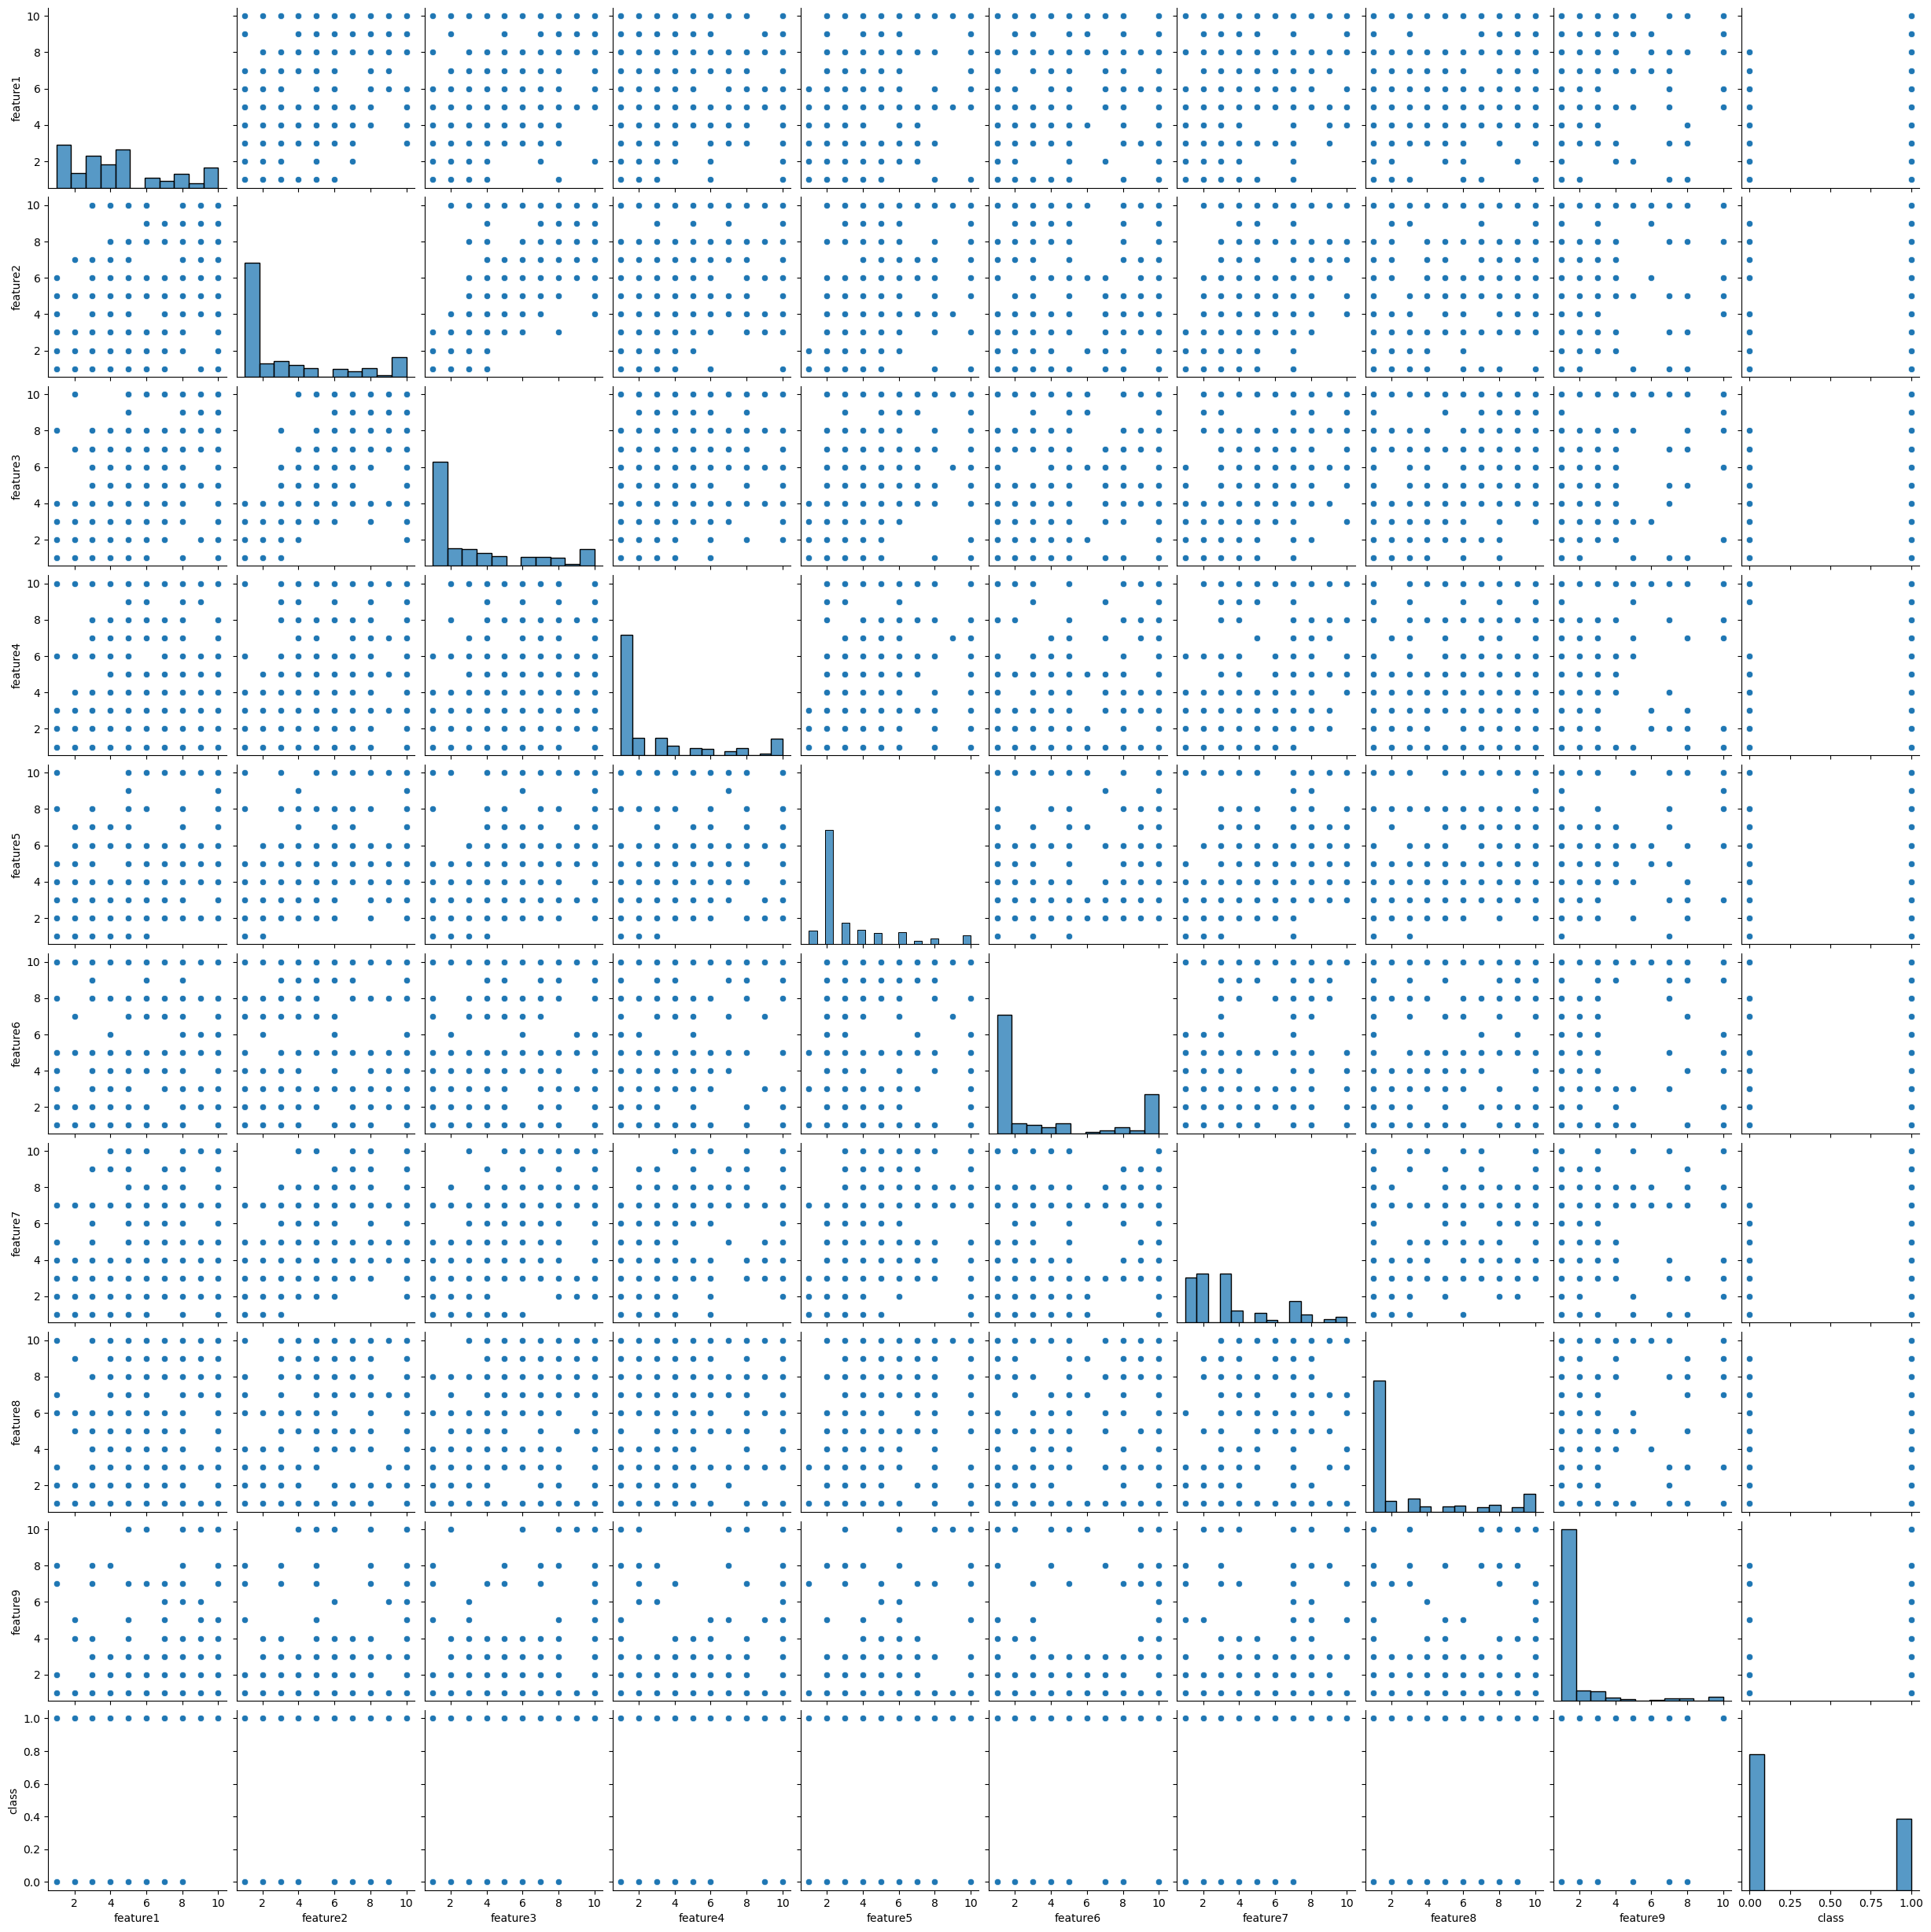

In [14]:
sns.pairplot(inp)
#pairplot of each attribute 

In [15]:
#univariate analysis

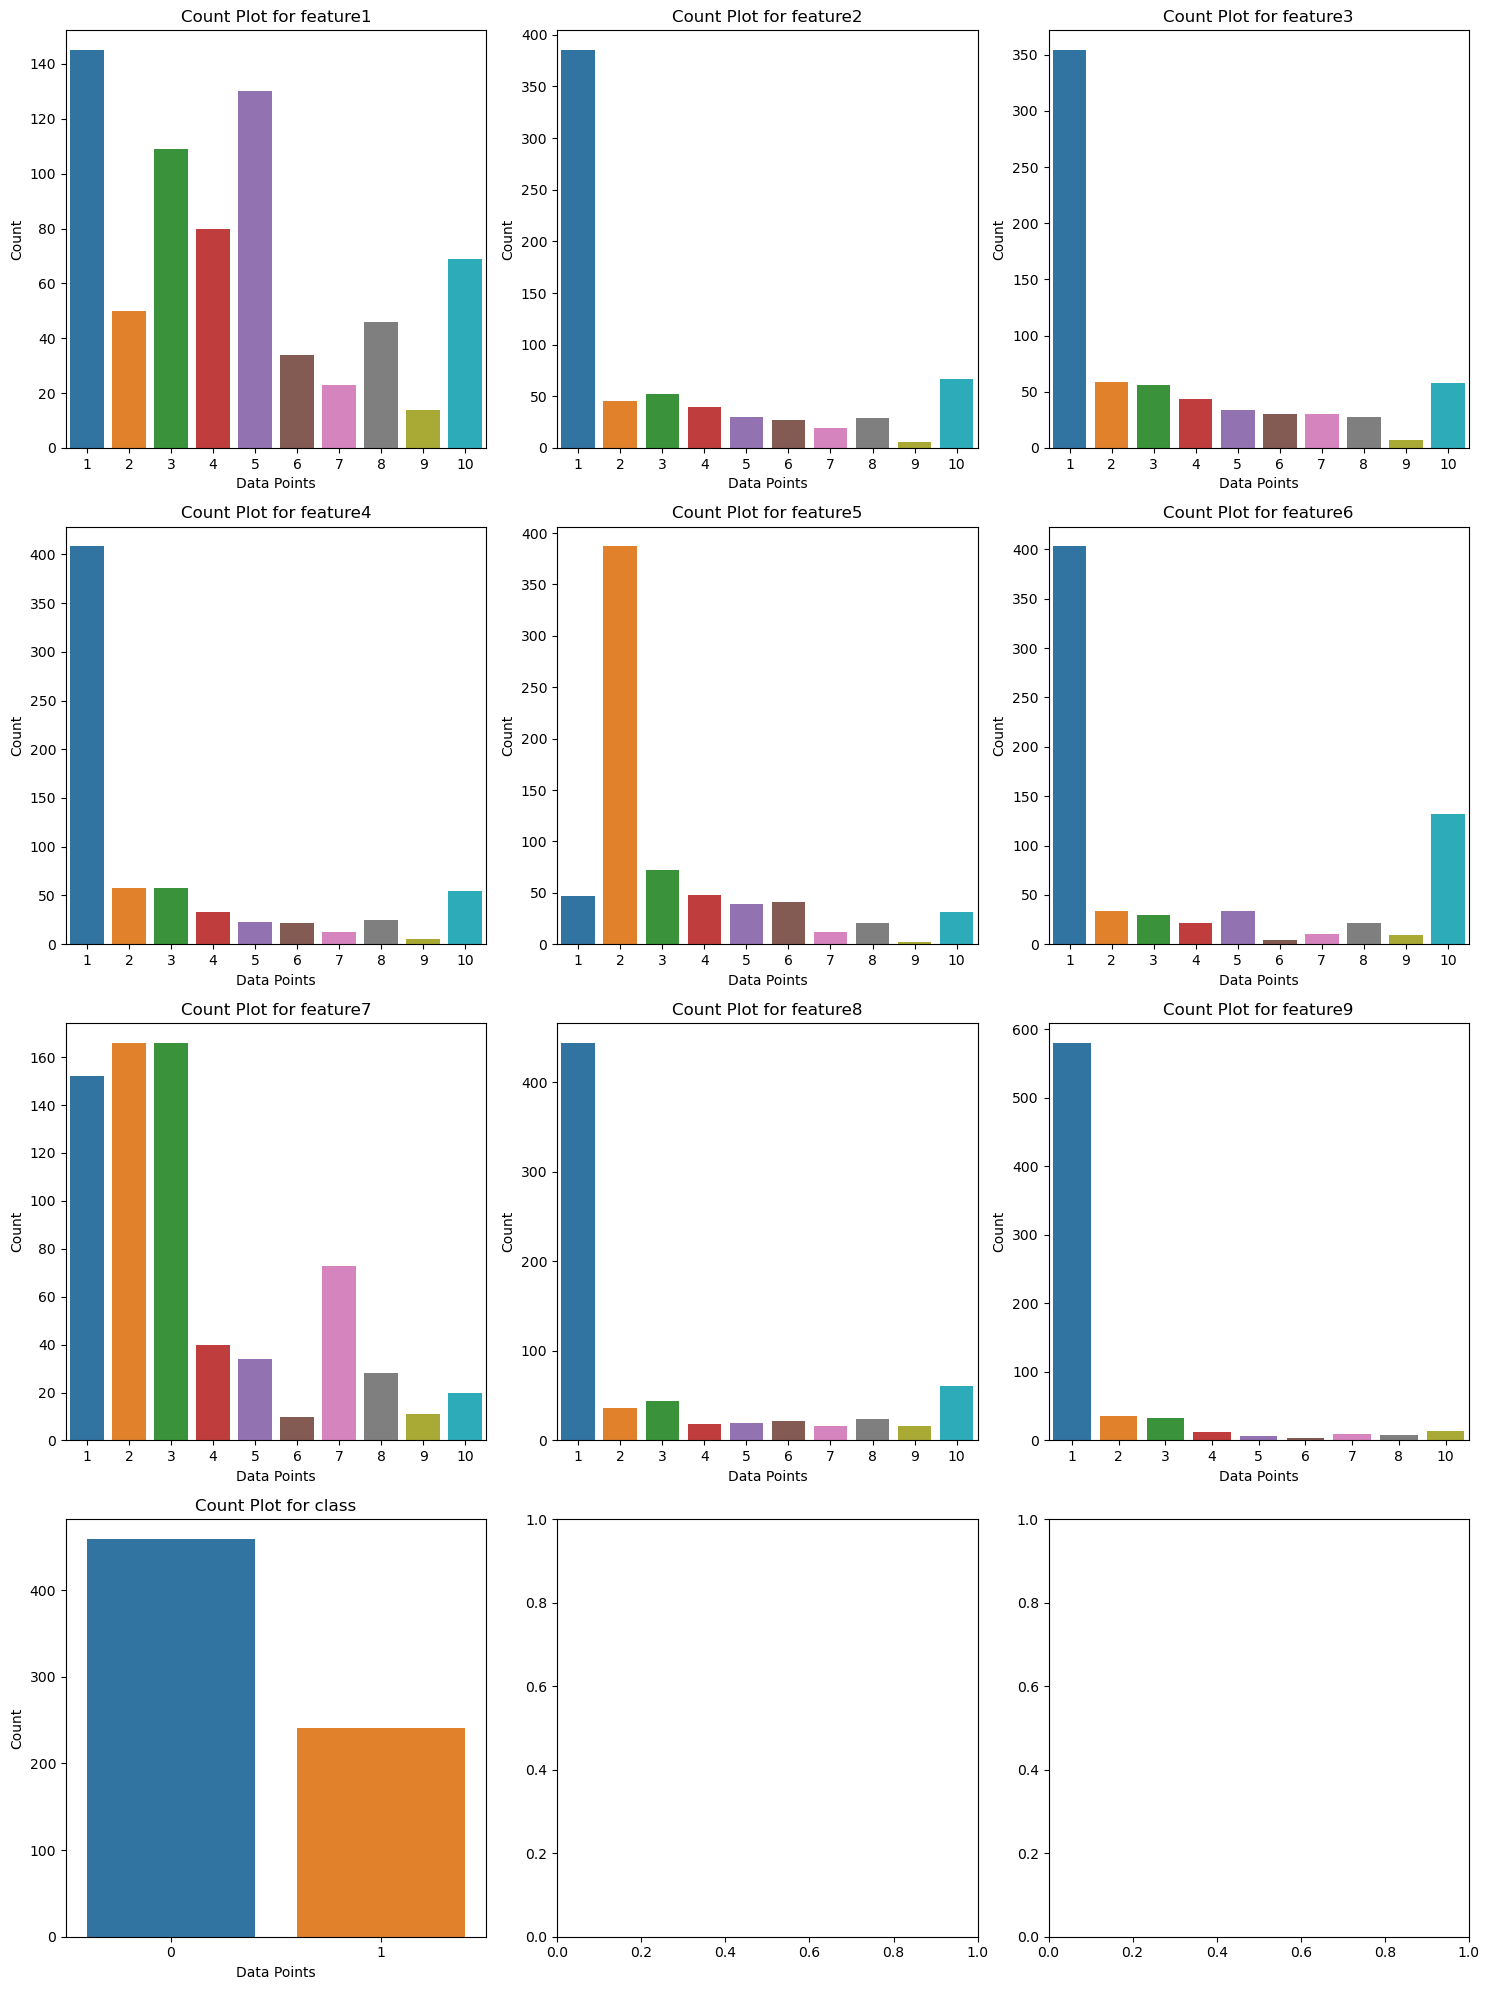

In [16]:
num_plots = len(inp.columns) #tells us about the length of our data 
num_rows = (num_plots // 3) + (num_plots % 3 > 0)  # this adjust the number of rows for plot
num_cols = 3  # Define the number of columns

# will create the subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5*num_rows))

if num_plots == 1:
    axes = [axes]

# Runs a for loop. to iterate over each column and create the count plots
for i, column in enumerate(inp.columns):
    row = i // num_cols
    col = i % num_cols
    sns.countplot(data=inp, x=column, ax=axes[row][col])
    axes[row][col].set_title(f'Count Plot for {column}')
    axes[row][col].set_xlabel('Data Points')
    axes[row][col].set_ylabel('Count')


plt.tight_layout()
plt.show() #show the plot

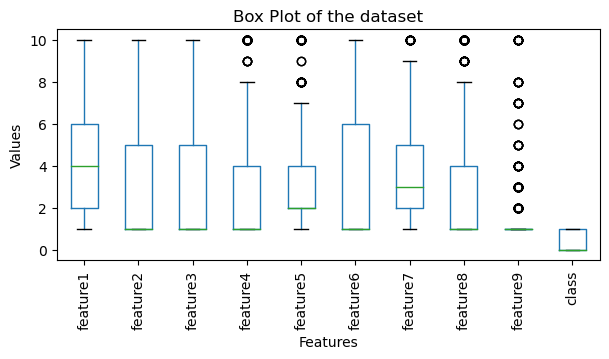

In [17]:
# we will create boxplots to check the outliers 
plt.figure(figsize=(7, 3))
inp.boxplot()
plt.title('Box Plot of the dataset')
plt.ylabel('Values')
plt.xlabel('Features')
plt.xticks(rotation=90)
plt.grid(False)
plt.show()

In [18]:
#as we can see that feature9,feature4,feature5,feature8 have outliers

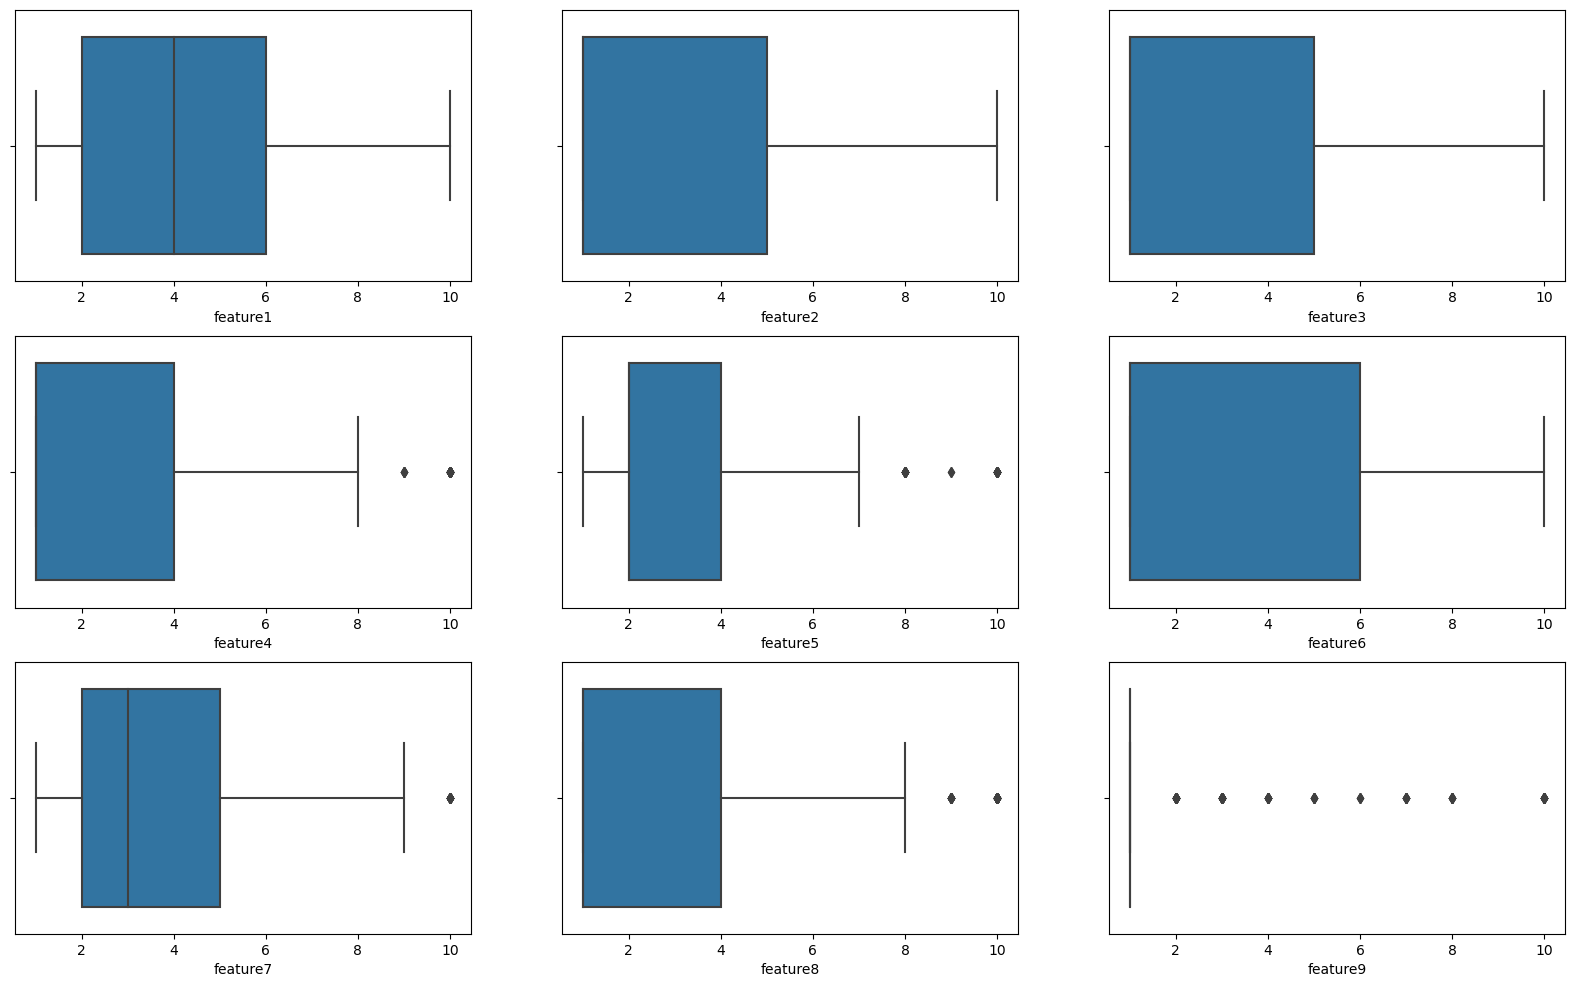

In [19]:
#confirms about the outliers by going through the attributes one by one
plt.figure(figsize=(20, 12))
plt.subplot(3,3,1)
sns.boxplot(x = 'feature1', data = inp)
plt.subplot(3,3,2)
sns.boxplot(x = 'feature2', data = inp)
plt.subplot(3,3,3)
sns.boxplot(x = 'feature3', data = inp)
plt.subplot(3,3,4)
sns.boxplot(x = 'feature4', data = inp)
plt.subplot(3,3,5)
sns.boxplot(x = 'feature5', data = inp)
plt.subplot(3,3,6)
sns.boxplot(x = 'feature6', data = inp)
plt.subplot(3,3,7)
sns.boxplot(x = 'feature7', data = inp)
plt.subplot(3,3,8)
sns.boxplot(x = 'feature8', data = inp)
plt.subplot(3,3,9)
sns.boxplot(x = 'feature9', data = inp)
plt.show()

In [20]:
# to confirm how much value lies in the given quartile

In [21]:
inp.describe(percentiles=[0.25,0.5,0.75,0.9,0.99])

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,class
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,4.415714,3.131429,3.204286,2.804286,3.214286,3.557143,3.437143,2.864286,1.588571,0.344286
std,2.814236,3.050343,2.970958,2.854153,2.213193,3.613026,2.436676,3.052265,1.713995,0.475475
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,0.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,1.000000
90%,9.000000,9.000000,8.000000,8.000000,6.000000,10.000000,7.000000,9.000000,3.000000,1.000000
99%,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000


In [22]:
#bivariate analysis

In [23]:
#Create plots with respect to the class attribute and tell us their count

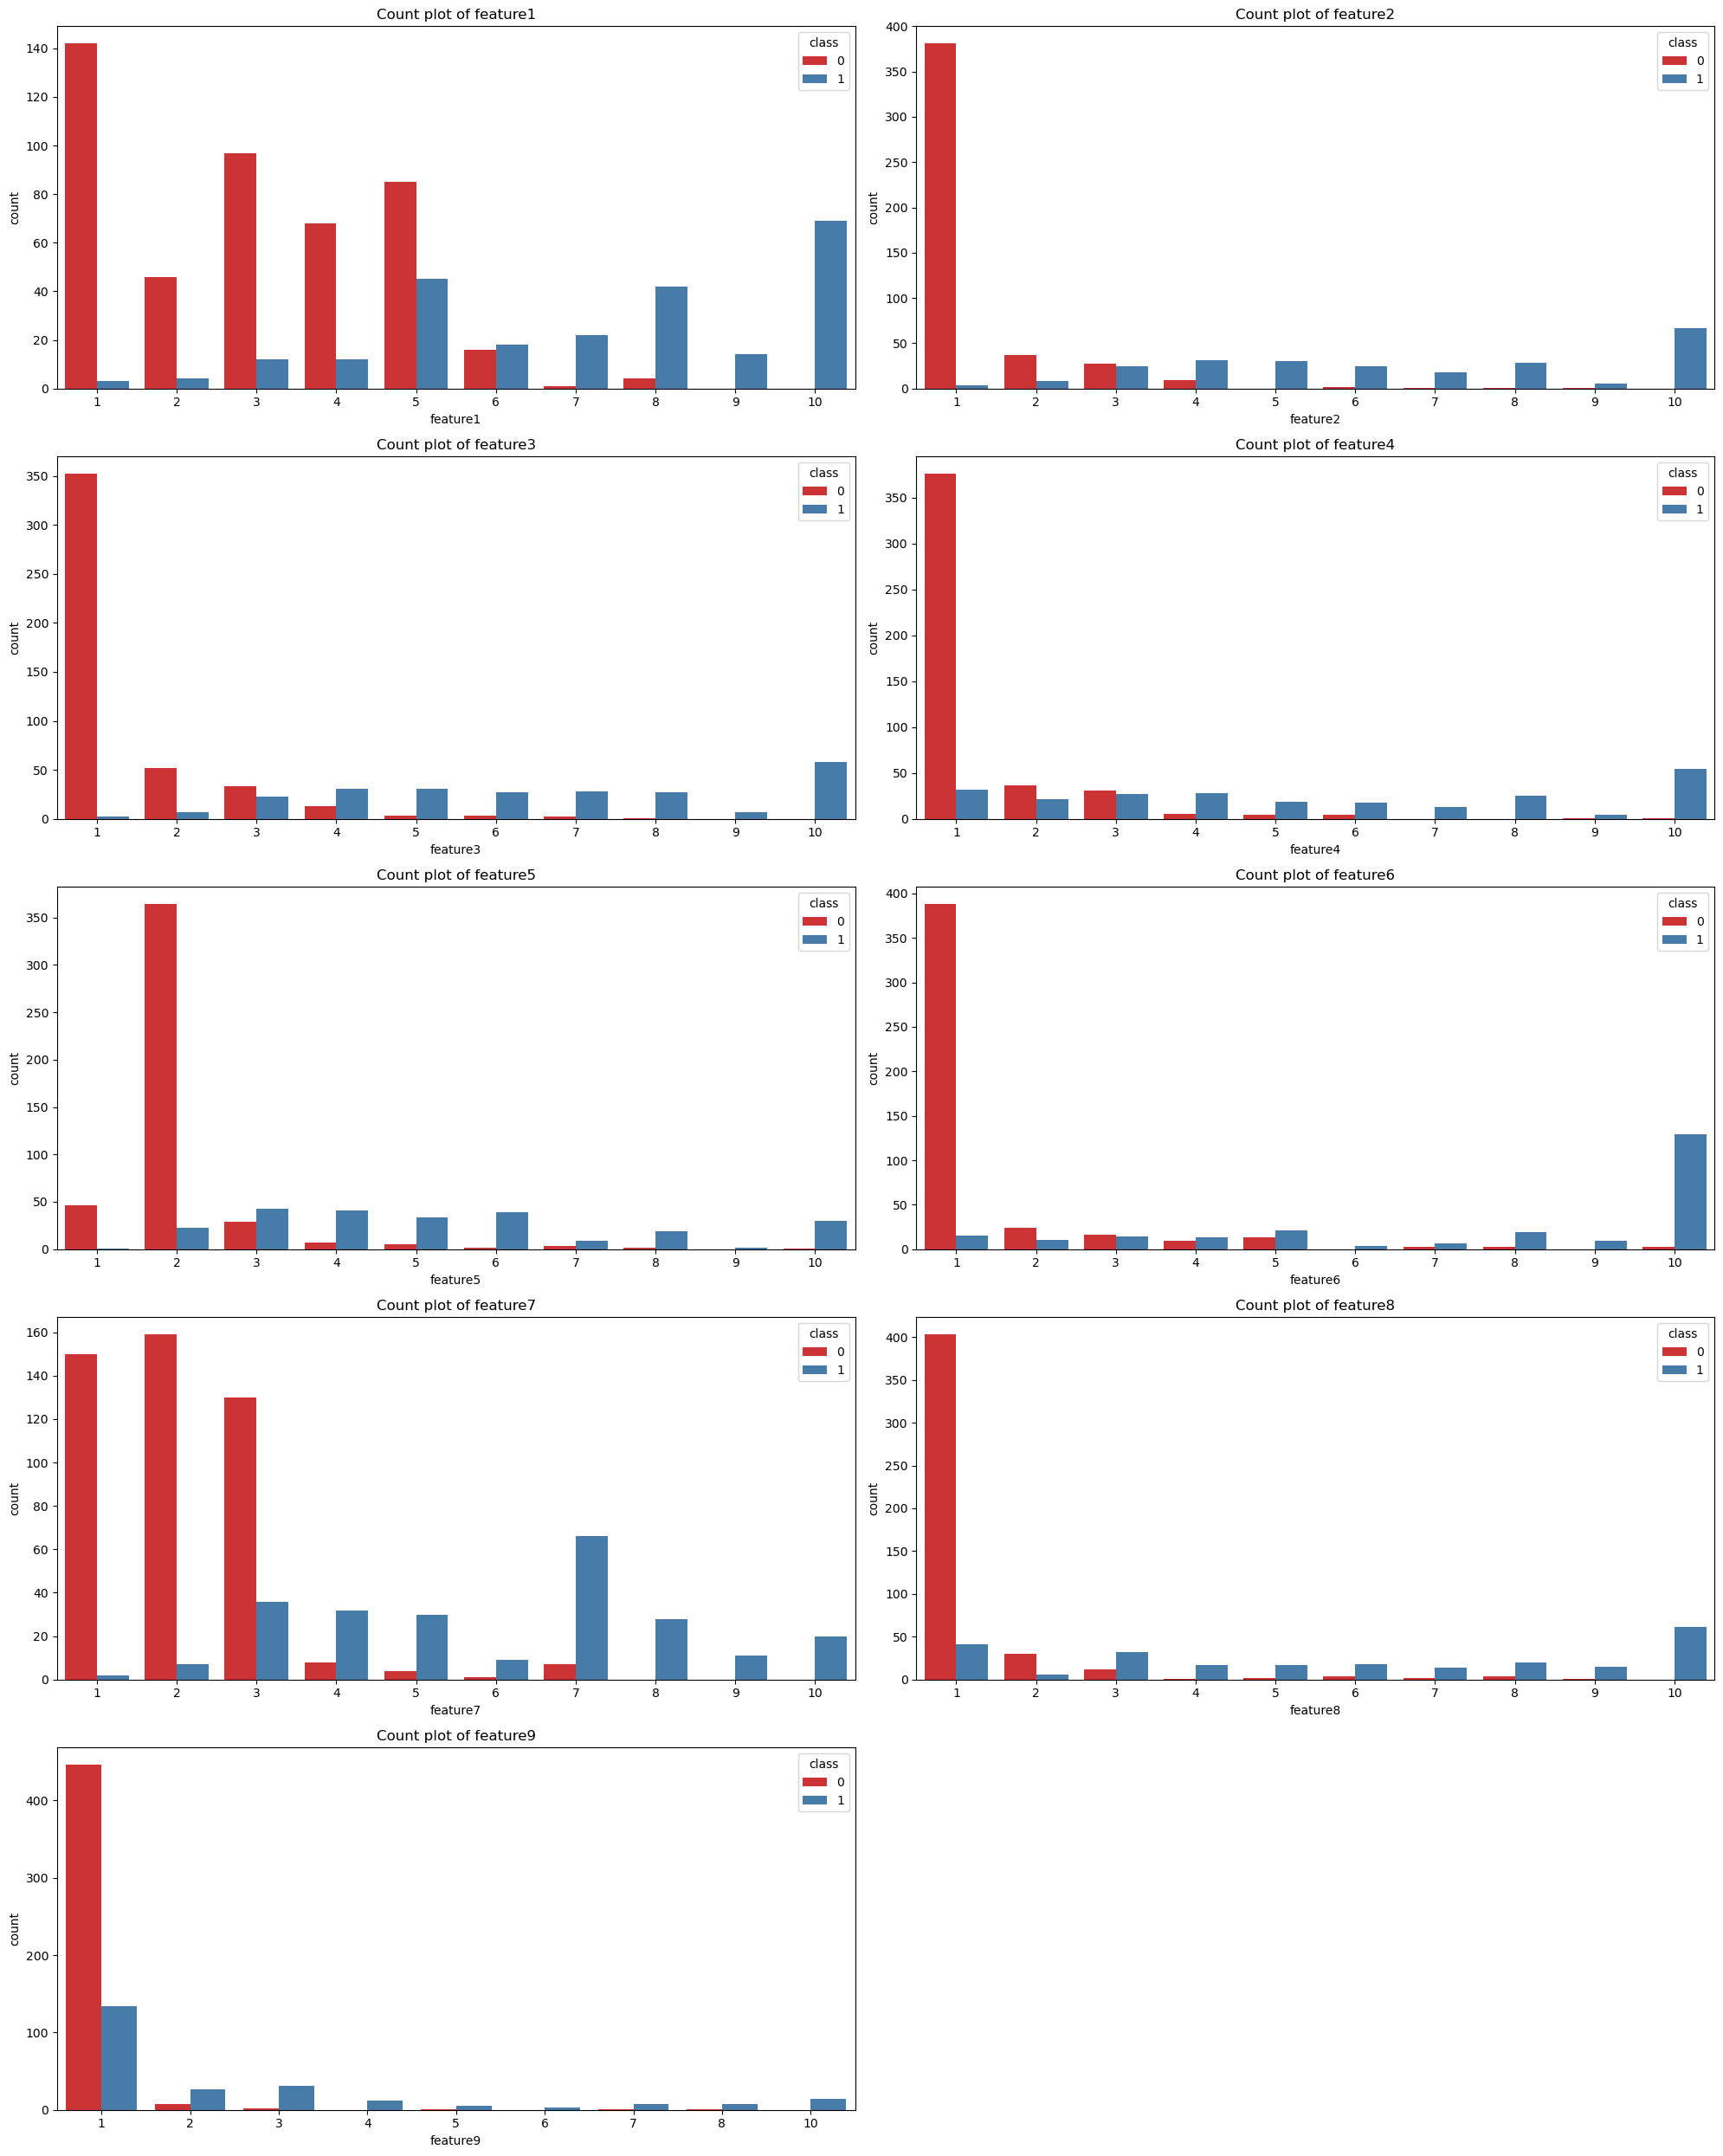

In [24]:
plt.figure(figsize=[20,25]) # determine the size of the plot

plt.subplot(5,2,1)
plt_1 = sns.countplot(x='feature1',data=inp,hue='class',palette="Set1") 
plt_1.set_xticklabels(plt_1.get_xticklabels())
plt.title('Count plot of feature1')

plt.subplot(5,2,2)
plt_2 = sns.countplot(x='feature2',data=inp,hue='class',palette="Set1") 
plt_2.set_xticklabels(plt_2.get_xticklabels())
plt.title('Count plot of feature2')

plt.subplot(5,2,3)
plt_3 = sns.countplot(x='feature3',data=inp,hue='class',palette="Set1") 
plt_3.set_xticklabels(plt_3.get_xticklabels())
plt.title('Count plot of feature3')

plt.subplot(5,2,4)
plt_4 = sns.countplot(x='feature4',data=inp,hue='class',palette="Set1") 
plt_4.set_xticklabels(plt_4.get_xticklabels())
plt.title('Count plot of feature4')

plt.subplot(5,2,5)
plt_5 = sns.countplot(x='feature5',data=inp,hue='class',palette="Set1") 
plt_5.set_xticklabels(plt_5.get_xticklabels())
plt.title('Count plot of feature5')

plt.subplot(5,2,6)
plt_6 = sns.countplot(x='feature6',data=inp,hue='class',palette="Set1") 
plt_6.set_xticklabels(plt_6.get_xticklabels())
plt.title('Count plot of feature6')

plt.subplot(5,2,7)
plt_7 = sns.countplot(x='feature7',data=inp,hue='class',palette="Set1") 
plt_7.set_xticklabels(plt_7.get_xticklabels())
plt.title('Count plot of feature7')

plt.subplot(5,2,8)
plt_8 = sns.countplot(x='feature8',data=inp,hue='class',palette="Set1") 
plt_8.set_xticklabels(plt_8.get_xticklabels())
plt.title('Count plot of feature8')

plt.subplot(5,2,9)
plt_9 = sns.countplot(x='feature9',data=inp,hue='class',palette="Set1") 
plt_9.set_xticklabels(plt_9.get_xticklabels())
plt.title('Count plot of feature9')


plt.tight_layout()
plt.show() # show the plots


In [25]:
#multivariate analysis

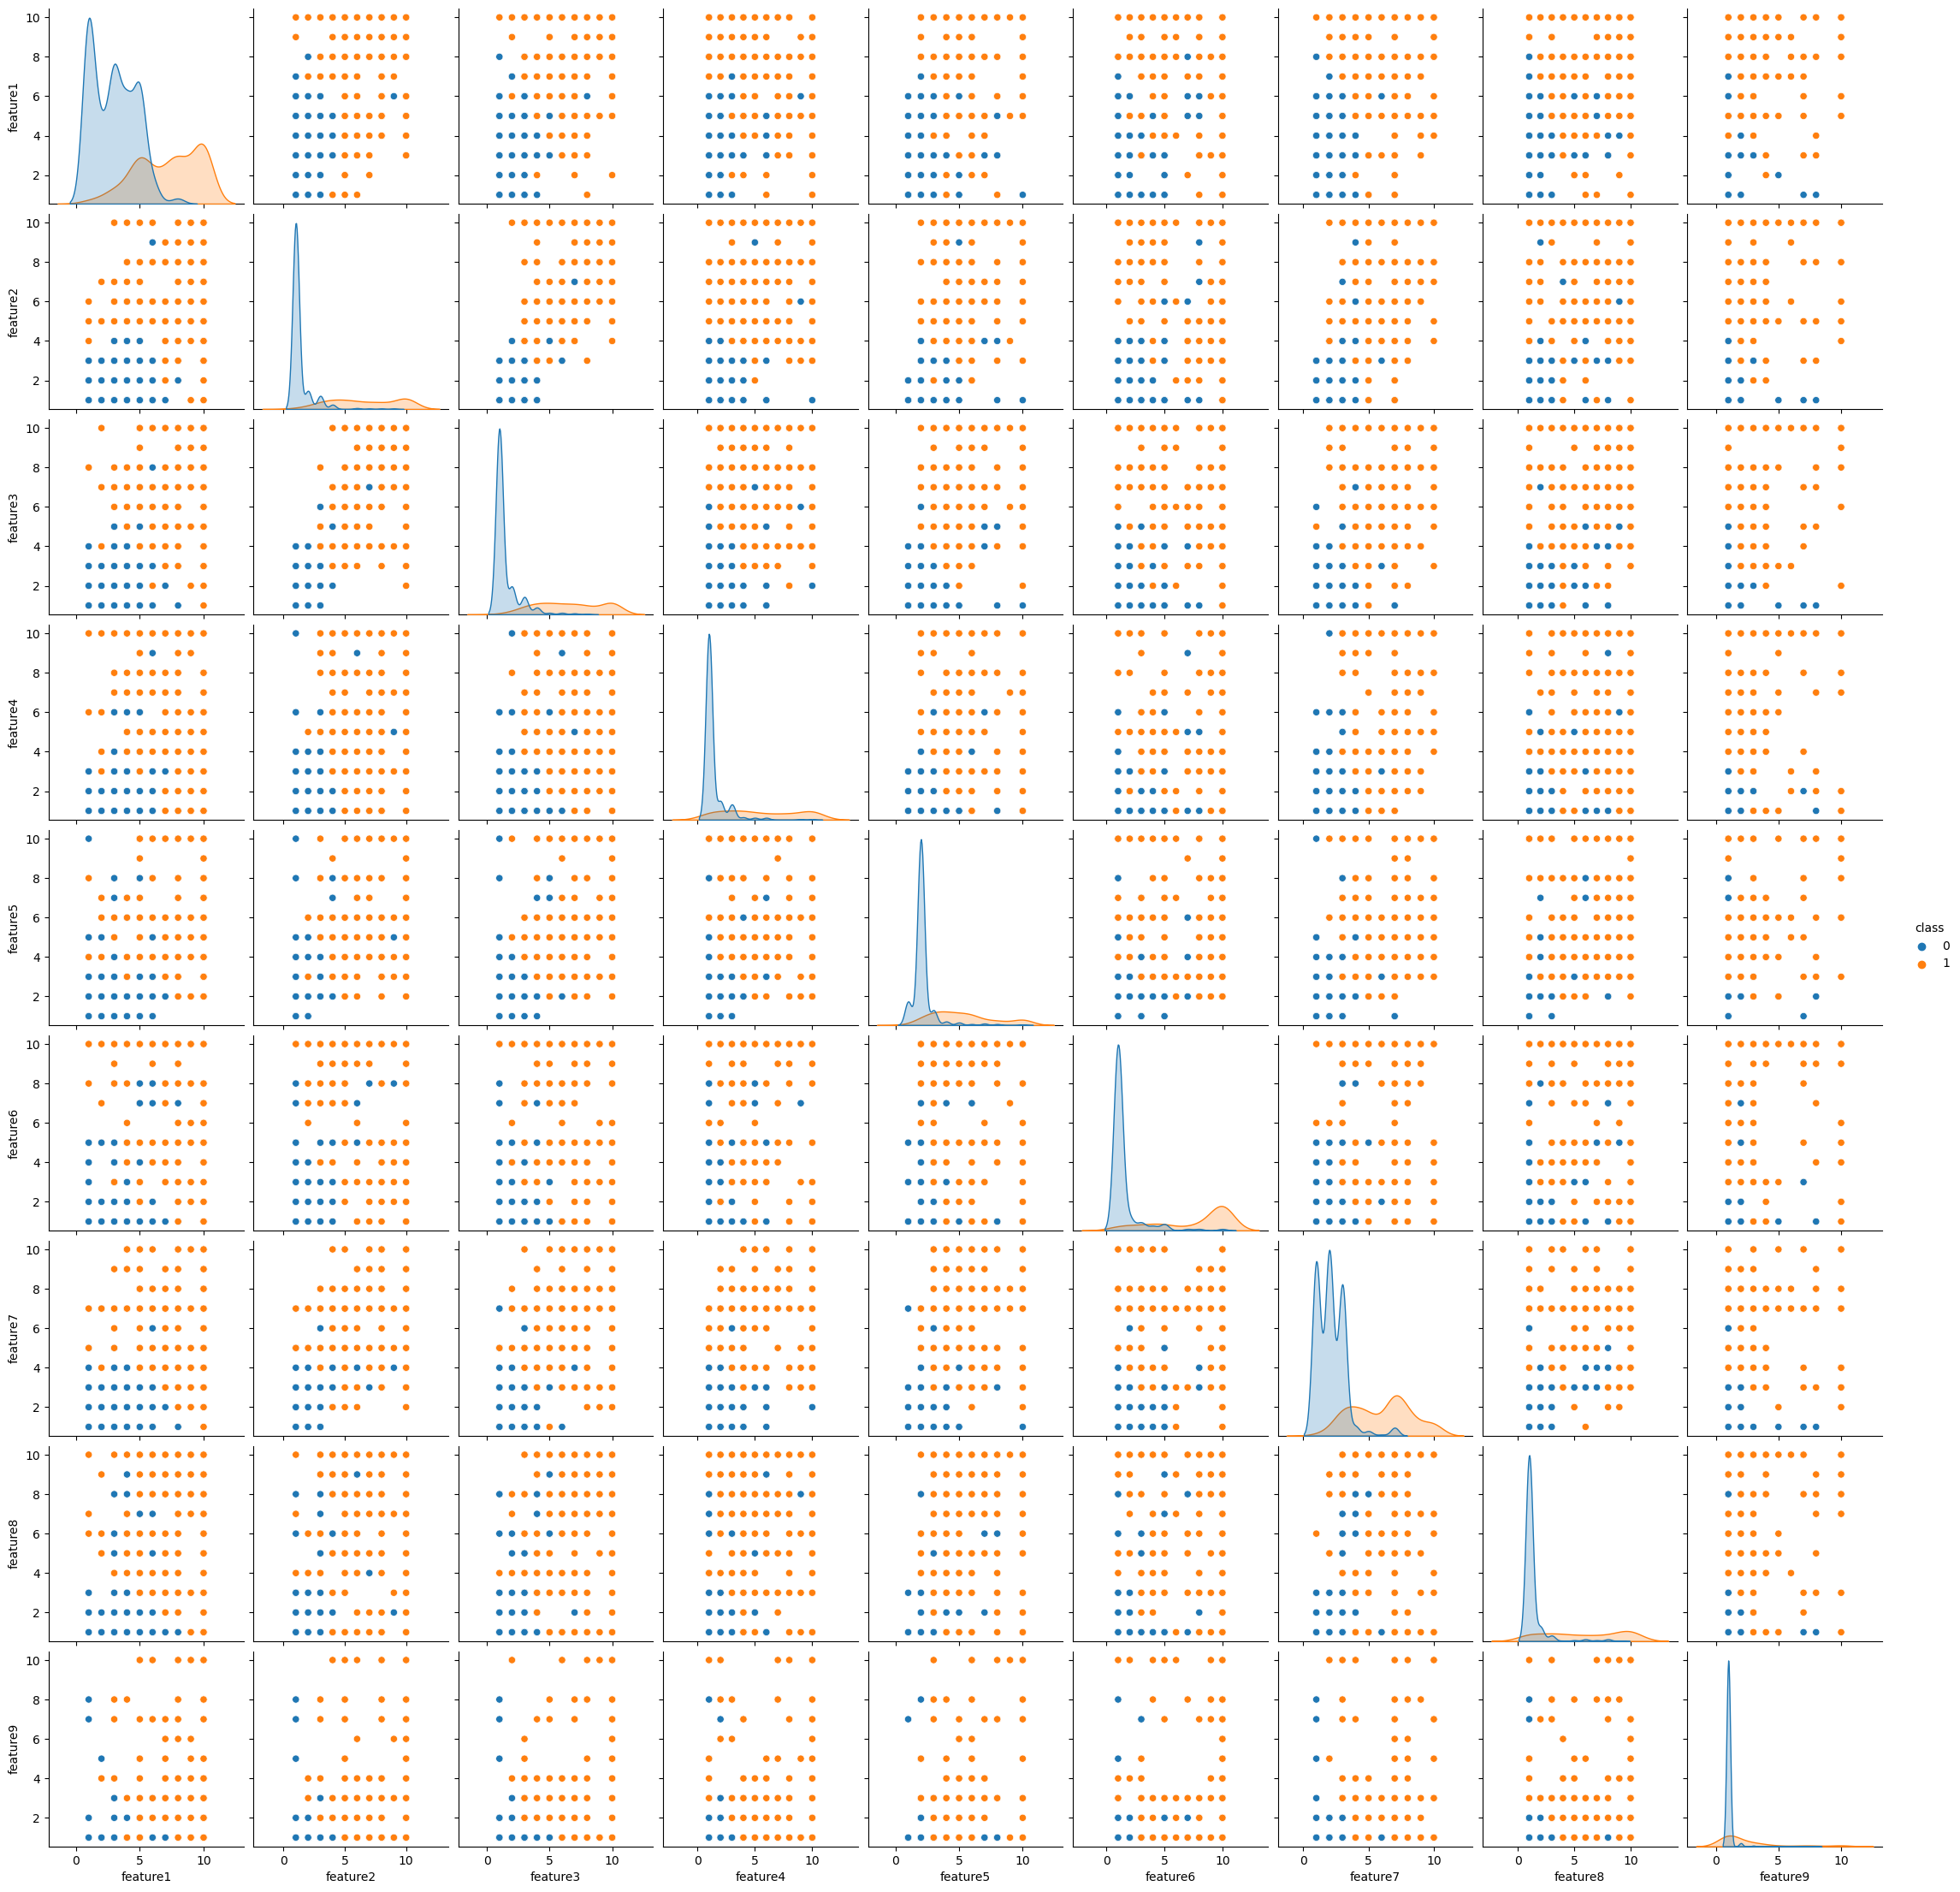

In [26]:
sns.pairplot(inp,hue='class')

In [27]:
#we will generate a heatmap to find the correlation between the attributes of our data

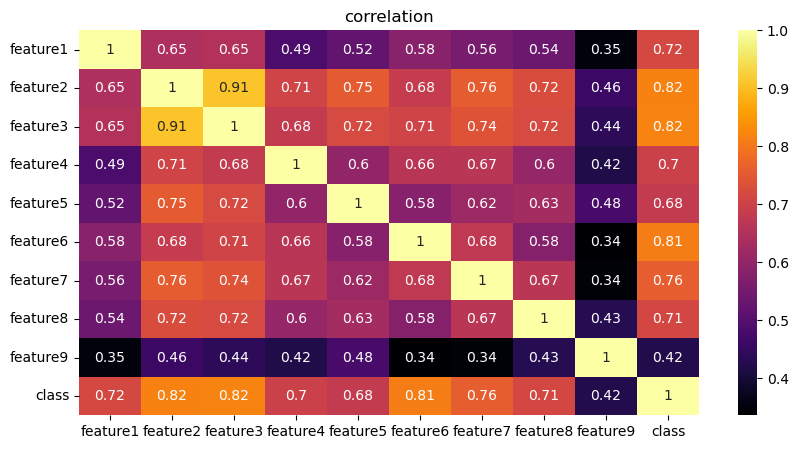

In [28]:
plt.figure(figsize=(10,5)) 
sns.heatmap(inp.corr(), annot=True, cmap="inferno").set(title='correlation')
plt.show()

In [29]:
#High correlation between two variables means that there is a strong linear relationship between them
# as we can see feature2 and feature3 has a high correlation of 0.91 
#feature2 and feature3 has high correlation with other attributes as well

# Model Training

In [30]:
# we will first fix the starting point using random seed 
np.random.seed(0)
#now we will split the data into train and test data sets 
inp_train, inp_test = train_test_split(inp, train_size = 0.8, random_state = 42,shuffle = True)

In [31]:
#the data has splitted

In [32]:
#check the shape of train dataset
inp_train.shape

(560, 10)

In [33]:
#check the shape of test dataset
inp_test.shape

(140, 10)

In [34]:
#we will now extract the features and target variables of training dataset
X_train = inp_train.drop('class', axis=1)#feature extraction
y_train = inp_train['class'] #target variable extraction

In [35]:
#Same as training dataset, extract the features and target variables of test dataset
X_test = inp_test.drop('class', axis=1) #feature extraction
y_test = inp_test['class']#target variable extraction

In [36]:
#again check the shape
X_train.shape

(560, 9)

In [37]:
#we will now scale our data and use standard scaler
#using scaler like StandardScaler ensures that the features are appropriately scaled 
#and helps improve the performance and stability of machine learning models

In [38]:
scaler = StandardScaler()

In [39]:
#now fit the scaler on the test and train dataset
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
#here as you can see for trainig dataset we use fit_transform
#while for test dataset we use transform because
#fit_transform is used for the initial fitting and transformation of the training data, 
#while transform is used for applying the same transformation to new data

In [41]:
data=[]# we introduce a new list to store all the models metrics 

In [42]:
confusion_mat = {} # this empty dictionary is introduced to store confusion matrix
#of each model

In [43]:
roc_data=[] # to store the data of roc curve a list is introduced

In [44]:
# now since we have divided our dataset into train test split we will now fit our data into the models

## Decision Tree

In [45]:
# first we will take decision tree as our model selection

In [46]:
deci_tree = DecisionTreeClassifier() # we call decision tree 

In [47]:
deci_tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [48]:
# we will first predict the model before hyperparameter
y_pred = deci_tree.predict(X_test)

#on the basis of model before tuning we will found all the metrices
accuracy_before_tuning = accuracy_score(y_test, y_pred) 
precision_before_tuning = precision_score(y_test, y_pred)
recall_before_tuning = recall_score(y_test, y_pred)
f1_before_tuning = f1_score(y_test, y_pred)
roc_auc_before_tuning = roc_auc_score(y_test, y_pred)
print("Accuracy before hyperparameter tuning:", accuracy_before_tuning)
print("Precision before hyperparameter tuning:", precision_before_tuning)
print("Recall before hyperparameter tuning:", recall_before_tuning)
print("f1 before hyperparameter tuning:", f1_before_tuning)
print("Roc_auc before hyperparameter tuning:", roc_auc_before_tuning)

Accuracy before hyperparameter tuning: 0.9357142857142857
Precision before hyperparameter tuning: 0.9302325581395349
Recall before hyperparameter tuning: 0.8695652173913043
f1 before hyperparameter tuning: 0.898876404494382
Roc_auc before hyperparameter tuning: 0.9188251618871415


In [49]:
#now let us specifiy some hyperparameters on the basis of which
#hyperparameter tuning of decision tree will be done 
#we will use grid search technique to explore these hyperparameters
param_grid = {'criterion': ['gini', 'entropy'],
              'max_depth': [None, 5, 10, 20, 30, 40, 50],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4,5]}

In [50]:
#now we will use grid search to tune our model and fit it
grid_search = GridSearchCV(estimator=deci_tree, param_grid=param_grid, cv=5, n_jobs=-1, scoring='f1')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 20, 30, 40, 50],
                         'min_samples_leaf': [1, 2, 4, 5],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

In [51]:
# we get cv = 5 and scoring = f1 after trying different different value for each 
# check for cv = 3,5,10 
# check for scoring = accuracy, f1 and precision and recall

In [52]:
# this will search for the best params in the param_grid for optimal solution
best_params = grid_search.best_params_


In [53]:
# we have found the best hyperparameters for decision tree
#an now we will fit the model using those hyperparameters

In [54]:
decision_tree_best = DecisionTreeClassifier(**best_params)
decision_tree_best.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10)

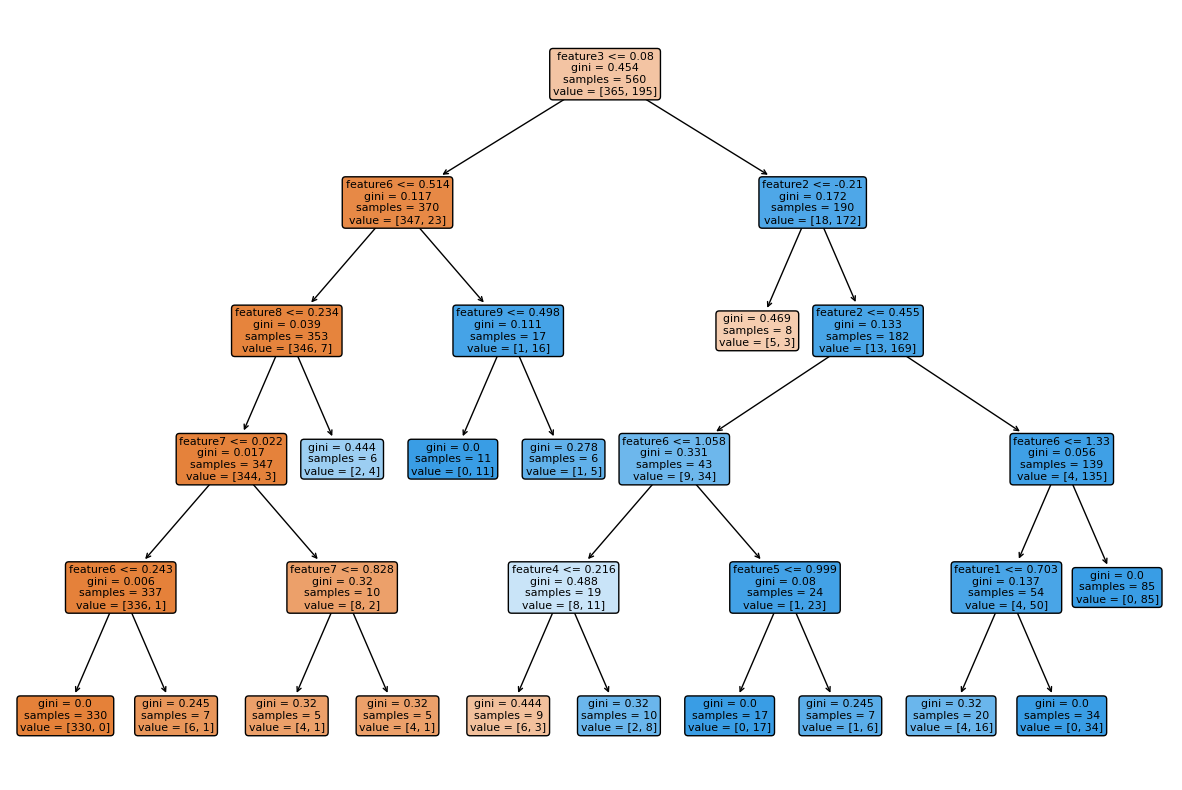

In [55]:
# we can also plot the decision tree with best hyperparameters with annotation
from sklearn.tree import plot_tree

# Plot decision tree with annotations
plt.figure(figsize=(15, 10))
plot_tree(decision_tree_best, filled=True, feature_names=['feature1', 'feature2', 'feature3', 'feature4', 'feature5', 'feature6',
       'feature7', 'feature8', 'feature9'], class_names= None, rounded=True)
plt.show()

In [56]:
#now we will predict the model 
y_pred = decision_tree_best.predict(X_test)

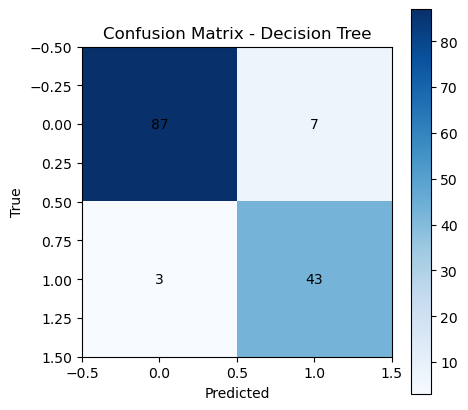

In [57]:
# we will now print the different metrices starting from 
# Confusion Matrix

conf_matrix_dt = confusion_matrix(y_test, y_pred) #find the confusion metrix value

confusion_mat['Decision Tree'] = conf_matrix_dt # load those value into the predefined dictionary 
#for later comparison

plt.figure(figsize=(5, 5))
plt.imshow(conf_matrix_dt, cmap='Blues', interpolation='nearest')

# Annotate each cell with the numeric value
for i in range(conf_matrix_dt.shape[0]):
    for j in range(conf_matrix_dt.shape[1]):
        plt.text(j, i, conf_matrix_dt[i, j], ha='center', va='center', color='black')

plt.colorbar()
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()




In [58]:
# now we will move to the other metrices 
#we will use accuracy ,precision, recall, and f1 to see the result of our model fitting

accuracy = accuracy_score(y_test, y_pred) 
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print("\nDecision Tree:")
print("Best Parameters:", best_params)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print(f"Test Scores (ROC_auc-Score): {roc_auc:.2f}")

# we will also append the result to the list of the data for comparison in the end
data.append({'Model': 'Decision Tree', 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1})


Decision Tree:
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 10}
Accuracy: 0.9285714285714286
Precision: 0.86
Recall: 0.9347826086956522
F1 Score: 0.8958333333333334
Test Scores (ROC_auc-Score): 0.93


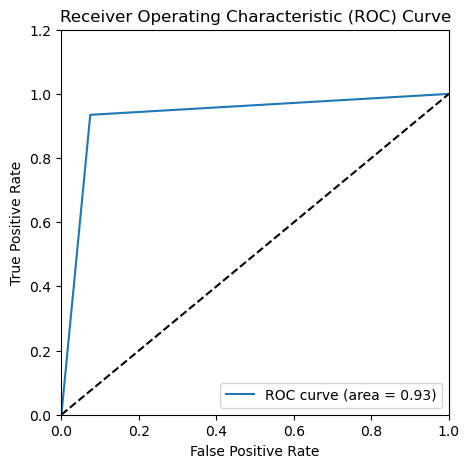

In [59]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.20])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


#store the value of ROC curve into a list for comparison at end
label = 'Decision Tree'
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
roc_data.append((fpr, tpr, roc_auc, label))

## RANDOM FOREST

In [60]:
# we will now choose random forest as our second model

In [61]:
rand_for = RandomForestClassifier()#call random forest

In [62]:
rand_for.fit(X_train, y_train)

RandomForestClassifier()

In [63]:
# we will first predict the model before hyperparameter
y_pred = rand_for.predict(X_test)

#on the basis of model before tuning we will found all the metrices
accuracy_before_tuning = accuracy_score(y_test, y_pred) 
precision_before_tuning = precision_score(y_test, y_pred)
recall_before_tuning = recall_score(y_test, y_pred)
f1_before_tuning = f1_score(y_test, y_pred)
roc_auc_before_tuning = roc_auc_score(y_test, y_pred)
print("Accuracy before hyperparameter tuning:", accuracy_before_tuning)
print("Precision before hyperparameter tuning:", precision_before_tuning)
print("Recall before hyperparameter tuning:", recall_before_tuning)
print("f1 before hyperparameter tuning:", f1_before_tuning)
print("Roc_auc before hyperparameter tuning:", roc_auc_before_tuning)

Accuracy before hyperparameter tuning: 0.9571428571428572
Precision before hyperparameter tuning: 0.9347826086956522
Recall before hyperparameter tuning: 0.9347826086956522
f1 before hyperparameter tuning: 0.9347826086956522
Roc_auc before hyperparameter tuning: 0.9514338575393155


In [64]:
#now let us specifiy some hyperparameters on the basis of which
#hyperparameter tuning of random forest will be done 
#we will use grid search technique to explore these hyperparameters
param_grid = {'n_estimators': [10, 50, 100, 200],
              'max_features': ['auto', 'sqrt', 'log2'],
              'max_depth': [None, 10, 20, 30, 40, 50],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4]}

In [65]:
#now we will use grid search to tune our model and fit it
grid_search = GridSearchCV(estimator=rand_for, param_grid=param_grid, cv=5, n_jobs=-1, scoring='f1')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30, 40, 50],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [10, 50, 100, 200]},
             scoring='f1')

In [66]:
# this will search for the best params in the param_grid for optimal solution
best_params = grid_search.best_params_

In [67]:
# we have found the best hyperparameters for Random Forest
#an now we will fit the model using those hyperparameters

In [68]:
rf_best = RandomForestClassifier(**best_params)
rf_best.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=4, min_samples_split=10,
                       n_estimators=10)

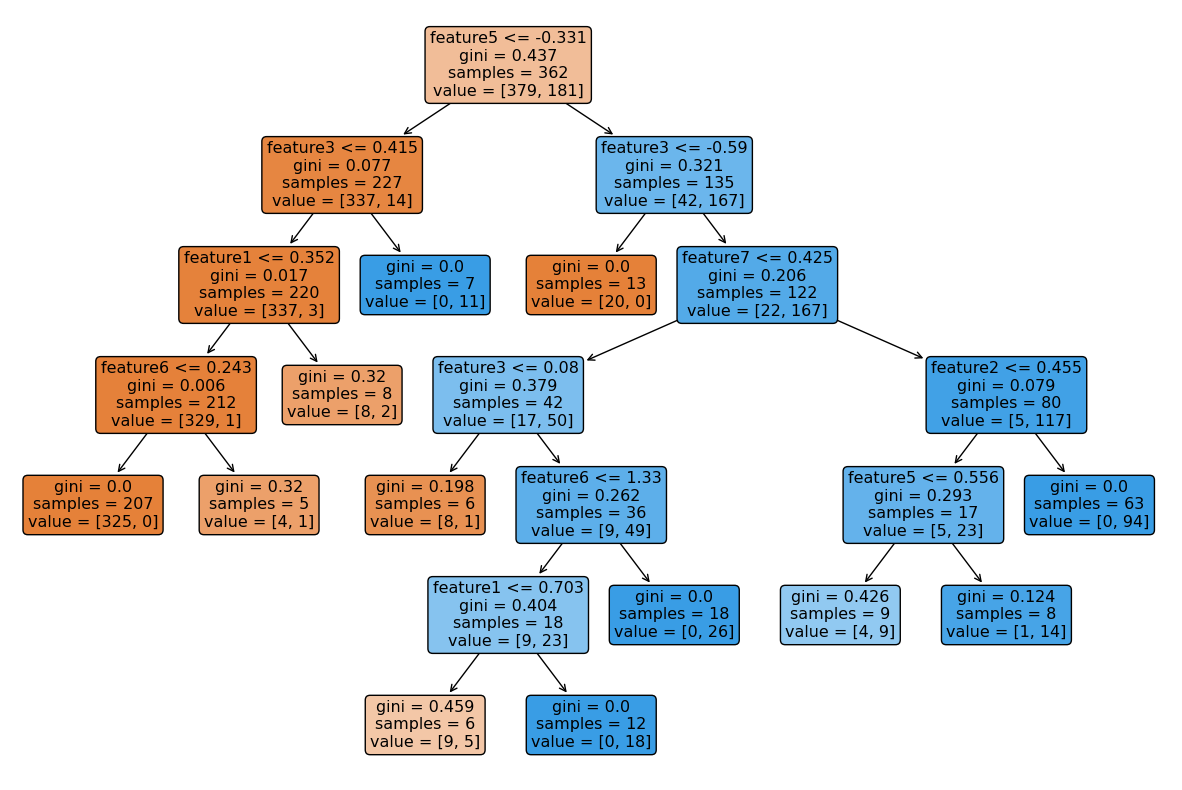

In [69]:
#Same as the decision tree we can also plot the random forest with best hyperparameters and with annotation
plt.figure(figsize=(15, 10))
plot_tree(rf_best.estimators_[0], filled=True, feature_names=['feature1', 'feature2', 'feature3', 'feature4', 'feature5', 'feature6',
       'feature7', 'feature8', 'feature9'], class_names=None, rounded=True)
plt.show()

In [70]:
#now we will predict the model 
y_pred = rf_best.predict(X_test)

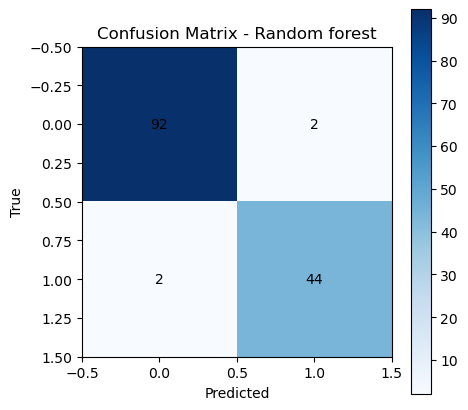

In [71]:
# we will now print the different metrices starting from 
# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred)
confusion_mat['Random Forest'] = conf_matrix_rf # load those value into the predefined dictionary 
#for later comparison

plt.figure(figsize=(5, 5))
plt.imshow(conf_matrix_rf, cmap='Blues', interpolation='nearest')

# Annotate each cell with the numeric value
for i in range(conf_matrix_rf.shape[0]):
    for j in range(conf_matrix_rf.shape[1]):
        plt.text(j, i, conf_matrix_rf[i, j], ha='center', va='center', color='black')

plt.colorbar()
plt.title('Confusion Matrix - Random forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [72]:
# now we will move to the other metrices 
#we will use accuracy ,precision, recall, and f1 to see the result of our model fitting

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print("\nRandom Forest:")
print("Best Parameters:", best_params)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print(f"Test Scores (ROC_auc-Score): {roc_auc:.2f}")

# we will also append the result to the list of the data for comparison in the end
data.append({'Model': 'Random Forest', 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1})



Random Forest:
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 10}
Accuracy: 0.9714285714285714
Precision: 0.9565217391304348
Recall: 0.9565217391304348
F1 Score: 0.9565217391304348
Test Scores (ROC_auc-Score): 0.97


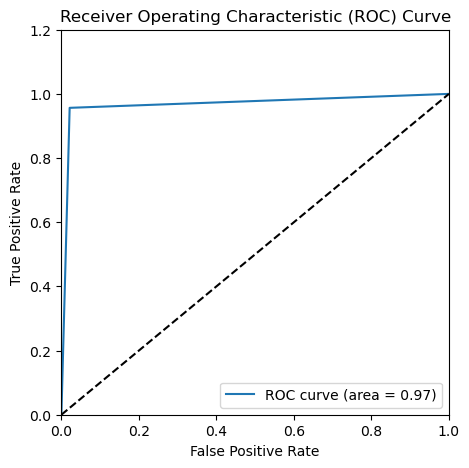

In [73]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.20])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

#store the value of ROC curve into a list for comparison at end
label = 'Random Forest'
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
roc_data.append((fpr, tpr, roc_auc, label))

## Support Vector Machine (SVM)

In [74]:
# we will now try to build our final model

In [75]:
svm = SVC()# we will call svm 

In [76]:
svm.fit(X_train, y_train)

SVC()

In [77]:
# we will first predict the model before hyperparameter
y_pred = svm.predict(X_test)

#on the basis of model before tuning we will found all the metrices
accuracy_before_tuning = accuracy_score(y_test, y_pred) 
precision_before_tuning = precision_score(y_test, y_pred)
recall_before_tuning = recall_score(y_test, y_pred)
f1_before_tuning = f1_score(y_test, y_pred)
roc_auc_before_tuning = roc_auc_score(y_test, y_pred)
print("Accuracy before hyperparameter tuning:", accuracy_before_tuning)
print("Precision before hyperparameter tuning:", precision_before_tuning)
print("Recall before hyperparameter tuning:", recall_before_tuning)
print("f1 before hyperparameter tuning:", f1_before_tuning)
print("Roc_auc before hyperparameter tuning:", roc_auc_before_tuning)

Accuracy before hyperparameter tuning: 0.9714285714285714
Precision before hyperparameter tuning: 0.9565217391304348
Recall before hyperparameter tuning: 0.9565217391304348
f1 before hyperparameter tuning: 0.9565217391304348
Roc_auc before hyperparameter tuning: 0.9676225716928769


In [78]:
#now let us specifiy some hyperparameters on the basis of which
#hyperparameter tuning of SVM will be done 
#we will use grid search technique to explore these hyperparameters
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf', 'linear', 'poly']}

In [79]:
#now we will use grid search to tune our model and fit it
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, n_jobs=-1, scoring='f1')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'linear', 'poly']},
             scoring='f1')

In [80]:
# this will search for the best params in the param_grid for optimal solution
best_params = grid_search.best_params_

In [81]:
# we have found the best hyperparameters for Random Forest
#an now we will fit the model using those hyperparameters

In [82]:
svm_best = SVC(**best_params)
svm_best.fit(X_train, y_train)

SVC(C=100, gamma=0.01)

In [83]:
#now we will predict the model
y_pred = svm_best.predict(X_test)


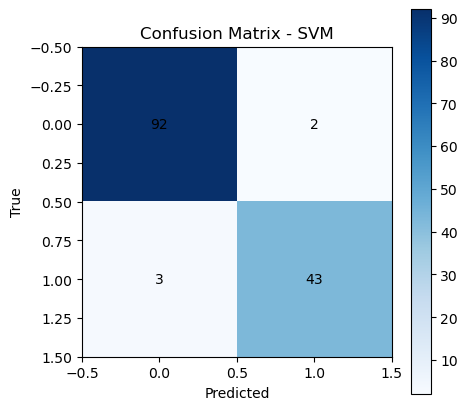

In [84]:
# we will now print the different metrices starting from
# Confusion Matrix
conf_matrix_sm = confusion_matrix(y_test, y_pred)
confusion_mat['SVM'] = conf_matrix_sm # load those value into the predefined dictionary 
#for later comparison


plt.figure(figsize=(5, 5))
plt.imshow(conf_matrix_sm, cmap='Blues', interpolation='nearest')

# Annotate each cell with the numeric value
for i in range(conf_matrix_sm.shape[0]):
    for j in range(conf_matrix_sm.shape[1]):
        plt.text(j, i, conf_matrix_sm[i, j], ha='center', va='center', color='black')

plt.colorbar()
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [85]:
# now we will move to the other metrices 
#we will use accuracy ,precision, recall, and f1 to see the result of our model fitting
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print("\nSupport Vector Machine:")
print("Best Parameters:", best_params)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print(f"Test Scores (ROC_auc-Score): {roc_auc:.2f}")

# we will also append the result to the list of the data for comparison in the end
data.append({'Model': 'Support Vector Machine', 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1})




Support Vector Machine:
Best Parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Accuracy: 0.9642857142857143
Precision: 0.9555555555555556
Recall: 0.9347826086956522
F1 Score: 0.945054945054945
Test Scores (ROC_auc-Score): 0.96


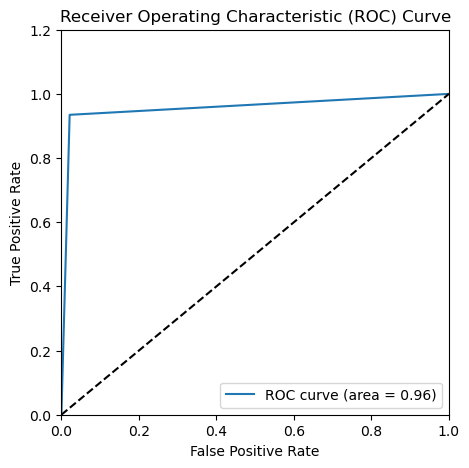

In [86]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.20])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

#store the value of ROC curve into a list for comparison at end
label = 'SVM'
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
roc_data.append((fpr, tpr, roc_auc, label))

### Now the model has been deployed and we got our result 

### we will now compare the results 

In [87]:
#convert the dictionary to dataframe
confusion_df = pd.DataFrame()

# Populate the DataFrame with confusion matrices
for model, conf_matrix in confusion_mat.items():
    # Flatten the confusion matrix
    flat_matrix = conf_matrix.flatten()
    # Add the flattened confusion matrix to the DataFrame
    confusion_df[model] = flat_matrix
index_labels = ['True Positive', 'True Negative', 'False Positive', 'False Negative']
confusion_df.index = index_labels
# Print the DataFrame
print(confusion_df)

                Decision Tree  Random Forest  SVM
True Positive              87             92   92
True Negative               7              2    2
False Positive              3              2    3
False Negative             43             44   43


In [88]:
# convert the list to data frame 
df = pd.DataFrame(data)
print(df)# print the dataframe to show the result so it can be compared

                    Model  Accuracy  Precision    Recall  F1 Score
0           Decision Tree  0.928571   0.860000  0.934783  0.895833
1           Random Forest  0.971429   0.956522  0.956522  0.956522
2  Support Vector Machine  0.964286   0.955556  0.934783  0.945055


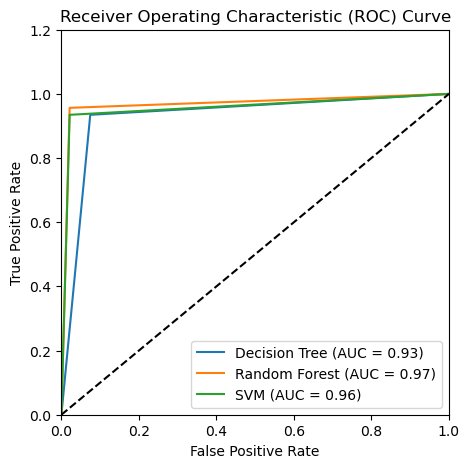

In [89]:
# use the roc_data the list we create before to compare the roc curve of each model
plt.figure(figsize=(5, 5))

# Iterate through each set of fpr, tpr, and roc_auc for different models
for fpr, tpr, roc_auc, label in roc_data:
    plt.plot(fpr, tpr, label='%s (AUC = %0.2f)' % (label, roc_auc))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.20])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
